<a href="https://colab.research.google.com/github/marcovirulucas/econ_apis/blob/main/united_states/FRED_02_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Federal Reserve Economic Data (FRED) API with Python
## Part 2 - Extraction
## Fed Projections, Oil Prices and PCE Inflation
------
*September 22, 2026*\
\
The FRED API documentation can be found [here](https://fred.stlouisfed.org/docs/api/fred/) (version 1) and [here](https://fred.stlouisfed.org/docs/api/fred/v2/index.html) (version 2). A free API key can be requested [here](https://fredaccount.stlouisfed.org/apikeys).\
\
This script downloads the FOMC Summary of Economic Projections (API v2, whole release) and the observed series of oil prices and PCE inflation (API v1, series by series).

In [1]:
import requests
import pandas as pd

### API key
Every request to FRED must include an API key. In Google Colab, save it in *Secrets* (key icon on the left panel) with the name `FRED_API_KEY`. Outside Colab, paste it directly in the cell below.

In [2]:
# Load the API key (never share it or upload it to GitHub)
try:
    from google.colab import userdata
    API_KEY = userdata.get('FRED_API_KEY')
except ImportError:
    import keys
    API_KEY = '{}'.format(keys.fred_key)

## A. Fed projections
### Base URL and Endpoint
API v2 has one endpoint, `release/observations`, which returns all the series of a release with their entire history. In v2 the API key is sent in the header of the request.

In [3]:
base = 'https://api.stlouisfed.org/fred/'
endpoint = 'v2/release/observations'
headers = {'Authorization': f'Bearer {API_KEY}'}

### Parameters

In [4]:
release_id = 326   # Summary of Economic Projections
params = {'release_id': release_id, 'format': 'json'}

### Request the data

In [5]:
# Make a request to an URL
resp = requests.get(base + endpoint, params=params, headers=headers)
data = resp.json()
data.keys()

dict_keys(['has_more', 'release', 'series'])

Large releases are delivered in pages. If `has_more` is `True`, we repeat the request with the `next_cursor` of the previous response until the last page.

In [6]:
# Collect every page of the release
series = data['series']
while data.get('has_more'):
    params['next_cursor'] = data['next_cursor']
    data = requests.get(base + endpoint, params=params, headers=headers).json()
    series += data['series']
len(series)

63

In [7]:
# Construct the dataframe (one row per series and date)
df = pd.json_normalize(series, record_path='observations', meta=['series_id', 'title', 'units'])
df['value'] = pd.to_numeric(df['value'], errors='coerce')   # missing values come as '.'
df

,date,value,series_id,title,units
0,2015-01-01,NaN,FEDTARCTH,FOMC Summary of Economic Projections for the F...,Percent
1,2016-01-01,NaN,FEDTARCTH,FOMC Summary of Economic Projections for the F...,Percent
2,2017-01-01,NaN,FEDTARCTH,FOMC Summary of Economic Projections for the F...,Percent
3,2018-01-01,NaN,FEDTARCTH,FOMC Summary of Economic Projections for the F...,Percent
4,2019-01-01,NaN,FEDTARCTH,FOMC Summary of Economic Projections for the F...,Percent
...,...,...,...,...,...
2454,2025-09-17,4.15,UNRATERMLR,Longer Run FOMC Summary of Economic Projection...,"Fourth Quarter, Percent"
2455,2025-12-10,4.15,UNRATERMLR,Longer Run FOMC Summary of Economic Projection...,"Fourth Quarter, Percent"
2456,2026-03-18,4.15,UNRATERMLR,Longer Run FOMC Summary of Economic Projection...,"Fourth Quarter, Percent"
2457,2026-06-17,4.15,UNRATERMLR,Longer Run FOMC Summary of Economic Projection...,"Fourth Quarter, Percent"


In [8]:
# Pivot data into a time-series table (dates as rows, series as columns) and sort chronologically
sep = df.set_index(['date', 'series_id'])['value'].unstack()
sep.index = pd.to_datetime(sep.index)
sep = sep.sort_index()

### Projections table
We select the median projections, as in the table of the BCRP Inflation Report (September 2026, p. 6).

In [9]:
medians = {'GDPC1MD': 'Real GDP growth', 'UNRATEMD': 'Unemployment rate', 'PCECTPIMD': 'PCE inflation',
           'JCXFEMD': 'Core PCE inflation', 'FEDTARMD': 'Federal funds rate'}
first_year = 2026

# Annual projections: rows are variables, columns are years
table = sep.loc[sep.index.year >= first_year, list(medians)].dropna(how='all')
table.index = table.index.year
table = table.rename(columns=medians).T

# Longer-run projections: last available value of each LR series (core PCE has no LR projection)
lr = {k + 'LR': v for k, v in medians.items() if k + 'LR' in sep.columns}
table['Longer run'] = sep[list(lr)].ffill().iloc[-1].rename(lr)
table

date,2026,2027,2028,2029,Longer run
series_id,,,,,
Real GDP growth,2.3,2.4,2.2,2.1,2.0
Unemployment rate,4.1,4.1,4.1,4.1,4.2
PCE inflation,3.7,2.3,2.1,2.0,2.0
Core PCE inflation,3.4,2.5,2.2,2.0,NaN
Federal funds rate,4.1,4.1,3.9,3.6,3.2


## B. Oil prices and PCE inflation: series by series (API v1)
### Base URL and Endpoint
To download individual series we use the v1 endpoint `series/observations`. In v1 the API key is sent as a parameter.

In [10]:
endpoint = 'series/observations'

### Parameters
To download more series, add their IDs to the `series_ids` list.

In [11]:
series_ids = ['PCEPI', 'PCEPILFE', 'MCOILWTICO']
start = '2014-01-01'

### Request the data

In [12]:
# Make one request per series and stack the results
frames = []
for s in series_ids:
    params = {'series_id': s, 'observation_start': start, 'api_key': API_KEY, 'file_type': 'json'}
    resp = requests.get(base + endpoint, params=params)
    obs = pd.DataFrame(resp.json()['observations'])
    obs['series_id'] = s
    frames.append(obs)

# Construct the dataframe
df = pd.concat(frames)
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df

,realtime_start,realtime_end,date,value,series_id
0,2026-09-21,2026-09-21,2014-01-01,96.614,PCEPI
1,2026-09-21,2026-09-21,2014-02-01,96.660,PCEPI
2,2026-09-21,2026-09-21,2014-03-01,96.815,PCEPI
3,2026-09-21,2026-09-21,2014-04-01,96.987,PCEPI
4,2026-09-21,2026-09-21,2014-05-01,97.147,PCEPI
...,...,...,...,...,...
147,2026-09-22,2026-09-22,2026-04-01,100.320,MCOILWTICO
148,2026-09-22,2026-09-22,2026-05-01,102.130,MCOILWTICO
149,2026-09-22,2026-09-22,2026-06-01,84.810,MCOILWTICO
150,2026-09-22,2026-09-22,2026-07-01,80.460,MCOILWTICO


In [13]:
# Pivot data into a time-series table (dates as rows, series as columns) and sort chronologically
result = df.set_index(['date', 'series_id'])['value'].unstack()
result.index = pd.to_datetime(result.index)
result = result.sort_index()

In [14]:
# Calculate inflation (12-month percent change of the price indexes)
inflation = (result[['PCEPI', 'PCEPILFE']].pct_change(12, fill_method=None) * 100).round(1)
data = inflation.join(result['MCOILWTICO']).iloc[12:]   # the first 12 months have no inflation
data.tail(4)

,PCEPI,PCEPILFE,MCOILWTICO
date,,,
2026-05-01,4.1,3.5,102.13
2026-06-01,3.7,3.3,84.81
2026-07-01,3.7,3.3,80.46
2026-08-01,NaN,NaN,83.90


### Plot the results
The Fed projects inflation for the fourth quarter of each year (Q4/Q4). We show the median projections as points in December of each year.

In [15]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white')
plt.rc('axes', edgecolor='white', axisbelow=True)

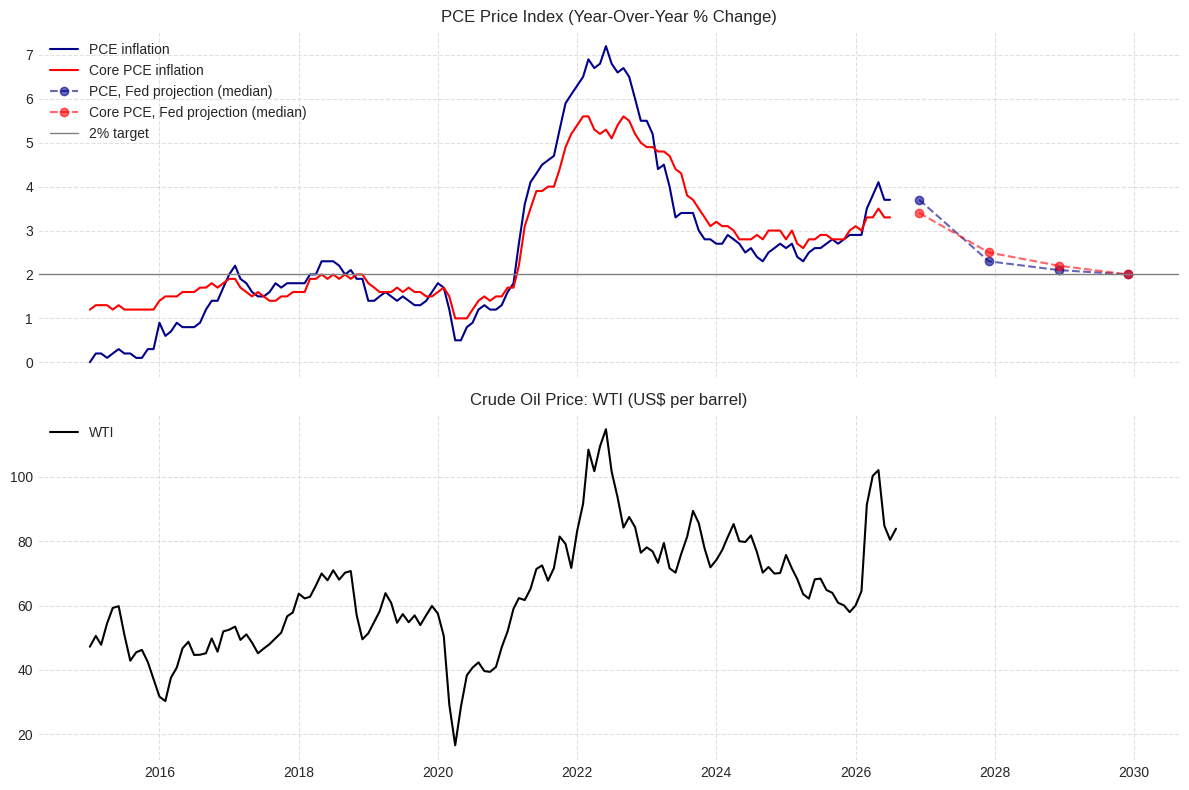

In [16]:
# Median projections of the Fed, placed in December of each year
proj = sep.loc[sep.index.year >= first_year, ['PCECTPIMD', 'JCXFEMD']].dropna(how='all')
proj.index = pd.to_datetime(proj.index.year.astype(str) + '-12-01')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: PCE inflation and Fed projections
ax1.plot(data['PCEPI'], color='darkblue', label='PCE inflation')
ax1.plot(data['PCEPILFE'], color='red', label='Core PCE inflation')
ax1.plot(proj['PCECTPIMD'], 'o--', color='darkblue', alpha=0.6, label='PCE, Fed projection (median)')
ax1.plot(proj['JCXFEMD'], 'o--', color='red', alpha=0.6, label='Core PCE, Fed projection (median)')
ax1.axhline(2, color='gray', linewidth=1, label='2% target')
ax1.set_title('PCE Price Index (Year-Over-Year % Change)')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

# Panel 2: oil price
ax2.plot(data['MCOILWTICO'], color='black', label='WTI')
ax2.set_title('Crude Oil Price: WTI (US$ per barrel)')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()